In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scipy.stats import linregress

In [97]:
LLM_TEST_DATASET = "../data/raw/llm_test_dataset_20260206-172226.csv"

In [98]:
llm_test_df = pd.read_csv(LLM_TEST_DATASET, parse_dates=["dt"]) # dt is originally a string, keep it in the original format, unsure of if timezone specific or utc

### Basic EDA

- Columns
- Shape
- Null counts
- Statistics

In [99]:
llm_test_df.head(5)

,dt,buyer_country,buyer_region,seller_country,seller_region,logistics_provider,parcel_qty,sum_apt,sum_bwt
0,2025-01-01,ID,West Java,ID,Banten,J&T,31945,22125.70,46667.10
1,2025-01-01,MY,Johor,MY,Pahang,Ninja Van,22112,17236.96,37398.05
2,2025-01-01,MY,Selangor,MY,Negeri Sembilan,Pos Malaysia,16639,14421.88,25091.53
3,2025-01-01,TH,Songkhla,TH,Korat,Kerry Express,18926,12963.18,88948.68
4,2025-01-01,MY,Sarawak,MY,Penang,Ninja Van,21664,14648.78,111298.19


In [53]:
llm_test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54258 entries, 0 to 54257
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   dt                  54258 non-null  datetime64[us]
 1   buyer_country       54258 non-null  str           
 2   buyer_region        53772 non-null  str           
 3   seller_country      54258 non-null  str           
 4   seller_region       53740 non-null  str           
 5   logistics_provider  54258 non-null  str           
 6   parcel_qty          54258 non-null  int64         
 7   sum_apt             54258 non-null  float64       
 8   sum_bwt             54258 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(5)
memory usage: 3.7 MB


In [13]:
llm_test_df.shape

(54258, 9)

Seems like buyer_region, and seller_region have null values, see if empty strings or anything

In [33]:
llm_test_df[llm_test_df["buyer_region"].isnull()]

,dt,buyer_country,buyer_region,seller_country,seller_region,logistics_provider,parcel_qty,sum_apt,sum_bwt
12,2025-01-01,TH,NaN,TH,Uknown,J&T,27052,17000.39,117211.04
38,2025-01-01,ID,NaN,ID,NaN,Ninja Van,25436,15438.30,111930.51
163,2025-01-01,ID,NaN,ID,Banten,Pos Indonesia,14449,10167.59,63683.38
501,2025-01-02,PH,NaN,PH,Uknown,J&T,21444,11239.20,98396.02
543,2025-01-02,PH,NaN,PH,NCR,J&T,17533,11041.88,79253.87
...,...,...,...,...,...,...,...,...,...
53724,2025-06-29,TH,NaN,TH,Nakhon Sawan,J&T,12436,9266.86,54573.73
53913,2025-06-29,ID,NaN,ID,Jakarta,Pos Indonesia,8715,6491.23,37339.10
54006,2025-06-30,PH,NaN,PH,Central Visayas,Ninja Van,11080,7880.20,47633.18
54015,2025-06-30,MY,NaN,MY,Uknown,Pos Malaysia,11440,8402.35,65104.10


Funny theres an uknown marker

Check for other potential markers?

In [37]:
llm_test_df[llm_test_df["buyer_region"] == "Uknown"]

,dt,buyer_country,buyer_region,seller_country,seller_region,logistics_provider,parcel_qty,sum_apt,sum_bwt
24,2025-01-01,PH,Uknown,PH,NaN,Ninja Van,8843,5910.22,38778.54
318,2025-01-02,TH,Uknown,TH,Unknown,FedEx,12220,5888.95,56828.22
416,2025-01-02,ID,Uknown,ID,NaN,J&T,14183,8020.14,64253.87
1069,2025-01-04,TH,Uknown,TH,Phuket,Kerry Express,18478,10355.99,108088.10
1160,2025-01-04,PH,Uknown,PH,West Visayas,J&T,25775,18013.95,120903.73
...,...,...,...,...,...,...,...,...,...
53824,2025-06-29,PH,Uknown,PH,Calabarzon,J&T,9421,5466.35,42079.46
53883,2025-06-29,MY,Uknown,MY,Selangor,Pos Malaysia,8399,5450.54,50420.43
54076,2025-06-30,TH,Uknown,TH,BKK,Ninja Van,22415,13200.38,13230.29
54084,2025-06-30,ID,Uknown,ID,East Java,Pos Indonesia,19533,13514.86,87229.34


In [38]:
llm_test_df[llm_test_df["buyer_region"] == "Unknown"]

,dt,buyer_country,buyer_region,seller_country,seller_region,logistics_provider,parcel_qty,sum_apt,sum_bwt
60,2025-01-01,TH,Unknown,TH,Uknown,Ninja Van,13792,7187.11,65072.69
104,2025-01-01,ID,Unknown,ID,Uknown,Pos Indonesia,28755,17358.72,129232.81
128,2025-01-01,PH,Unknown,PH,Calabarzon,LBC Express,29100,18937.28,169019.76
482,2025-01-02,ID,Unknown,ID,Bali,J&T,19053,15204.52,85658.79
526,2025-01-02,MY,Unknown,MY,Selangor,Pos Malaysia,19300,12208.50,108359.92
...,...,...,...,...,...,...,...,...,...
52975,2025-06-26,PH,Unknown,PH,Calabarzon,2GO Express,33450,21733.41,154043.88
53280,2025-06-27,PH,Unknown,PH,NaN,DHL,28040,17956.78,124781.29
53692,2025-06-29,TH,Unknown,TH,Chonburi,Ninja Van,10296,6520.63,139679.54
53699,2025-06-29,TH,Unknown,TH,BKK,Ninja Van,25364,15811.54,109739.75


Got Unkown too?

In [40]:
llm_test_df['buyer_region'].unique()

<StringArray>
[        'West Java',             'Johor',          'Selangor',
          'Songkhla',           'Sarawak',            'Banten',
     'Ilocos Region',        'Chiang Mai',             'Korat',
             'Kedah',         'East Java',      'Central Java',
                 nan,        'Nonthaburi',      'Nakhon Sawan',
      'SOCCSKSARGEN',      'West Visayas',     'North Sumatra',
               'BKK',           'Jakarta',            'Uknown',
               'NCR',       'Surat Thani',      'Bicol Region',
      'Kuala Lumpur',             'Sabah',   'Central Visayas',
    'South Sulawesi',         'Khon Kaen',   'Negeri Sembilan',
            'Pahang',            'Penang',           'Unknown',
              'Bali',        'Calabarzon',            'Phuket',
     'Central Luzon', 'Northern Mindanao',          'Chonburi',
              'Riau',                'SG',             'Perak']
Length: 42, dtype: str

In [41]:
llm_test_df['seller_region'].unique()

<StringArray>
[           'Banten',            'Pahang',   'Negeri Sembilan',
             'Korat',            'Penang',     'Ilocos Region',
          'Songkhla',       'Surat Thani',           'Sarawak',
              'Bali',     'North Sumatra',            'Uknown',
           'Unknown',         'Khon Kaen',        'Chiang Mai',
      'Bicol Region',      'Kuala Lumpur',        'Calabarzon',
    'South Sulawesi',        'Nonthaburi',                 nan,
               'NCR', 'Northern Mindanao',         'East Java',
               'BKK',      'Nakhon Sawan',         'West Java',
             'Perak',            'Phuket',      'SOCCSKSARGEN',
          'Chonburi',          'Selangor',      'West Visayas',
              'Riau',   'Central Visayas',     'Central Luzon',
             'Johor',             'Kedah',           'Jakarta',
                'SG',      'Central Java',             'Sabah']
Length: 42, dtype: str

In [43]:
llm_test_df['buyer_country'].unique()

<StringArray>
['ID', 'MY', 'TH', 'PH', 'SG']
Length: 5, dtype: str

In [44]:
llm_test_df['seller_country'].unique()

<StringArray>
['ID', 'MY', 'TH', 'PH', 'SG']
Length: 5, dtype: str

In [45]:
llm_test_df['logistics_provider'].unique()

<StringArray>
[          'J&T',     'Ninja Van',  'Pos Malaysia', 'Kerry Express',
       'SiCepat',         'FedEx',   '2GO Express', 'Pos Indonesia',
           'DHL',   'LBC Express',   'DB Schenker']
Length: 11, dtype: str

In [55]:
llm_test_df['dt'].describe()

count                         54258
mean     2025-04-01 00:13:35.304655
min             2025-01-01 00:00:00
25%             2025-02-15 00:00:00
50%             2025-04-01 00:00:00
75%             2025-05-16 00:00:00
max             2025-06-30 00:00:00
Name: dt, dtype: object

In [57]:
llm_test_df['parcel_qty'].describe()

count    54258.000000
mean     20610.973976
std       7477.283237
min          0.000000
25%      14420.000000
50%      20668.000000
75%      26433.000000
max      44968.000000
Name: parcel_qty, dtype: float64

In [106]:
llm_test_df[llm_test_df['parcel_qty'] == 0].head()

,dt,buyer_country,buyer_region,seller_country,seller_region,logistics_provider,parcel_qty,sum_apt,sum_bwt
745,2025-01-03,PH,NaN,PH,Uknown,2GO Express,0,0.0,0.0
996,2025-01-04,TH,BKK,TH,Surat Thani,J&T,0,0.0,0.0
1401,2025-01-05,TH,NaN,TH,Chonburi,Kerry Express,0,0.0,0.0
1526,2025-01-06,ID,Unknown,ID,NaN,DHL,0,0.0,0.0
1640,2025-01-06,PH,Ilocos Region,PH,Unknown,LBC Express,0,0.0,0.0


In [105]:
llm_test_df[llm_test_df['parcel_qty'] == 0]['sum_apt'].describe()

count    171.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: sum_apt, dtype: float64

In [104]:
llm_test_df[llm_test_df['parcel_qty'] == 0]['sum_bwt'].describe()

count    171.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: sum_bwt, dtype: float64

Means there are 0 parcel rows

In [59]:
llm_test_df[llm_test_df['parcel_qty'] == 0].count()

# but quite few, I think can just throw away?

dt                    171
buyer_country         171
buyer_region          136
seller_country        171
seller_region         138
logistics_provider    171
parcel_qty            171
sum_apt               171
sum_bwt               171
dtype: int64

In [68]:
def plot_route_grouped(llm_test_df: pd.DataFrame, yscale: str = "linear", out_file: Path | None = None, epsilon: float = 0.1):
    """
    Create a grouped bar chart of total parcels per route (seller_country -> buyer_country).

    Parameters
    - llm_test_df: DataFrame containing at least ['seller_country','buyer_country','parcel_qty']
    - yscale: 'linear' or 'log'
    - out_file: Path to save PNG (if None, will not save)
    - epsilon: small positive value used to replace zeros when yscale == 'log'
    """
    # Aggregate totals by route
    group = (
        llm_test_df.groupby(["seller_country", "buyer_country"], dropna=False)
        .agg(total_parcels=("parcel_qty", "sum"))
        .reset_index()
    )

    # Ensure full matrix (seller x buyer); fill missing with zeros
    sellers = sorted(llm_test_df["seller_country"].dropna().unique())
    buyers = sorted(llm_test_df["buyer_country"].dropna().unique())

    matrix = pd.DataFrame(0.0, index=sellers, columns=buyers)
    for _, row in group.iterrows():
        s = row["seller_country"]
        b = row["buyer_country"]
        matrix.at[s, b] = row["total_parcels"]

    # Plot grouped bars
    n_groups = len(sellers)
    n_bars = len(buyers)
    group_width = 0.8
    bar_width = group_width / max(1, n_bars)
    x = np.arange(n_groups)

    cmap = plt.get_cmap("tab10")
    colors = [cmap(i % 10) for i in range(n_bars)]

    fig, ax = plt.subplots(figsize=(12, 6))
    for i, buyer in enumerate(buyers):
        offsets = x - (group_width / 2) + i * bar_width + bar_width / 2
        values = matrix[buyer].values.astype(float)
        if yscale == "log":
            values = np.where(values <= 0, epsilon, values)
        ax.bar(offsets, values, width=bar_width, label=buyer, color=colors[i], edgecolor="k", linewidth=0.3)

    ax.set_xticks(x)
    ax.set_xticklabels(sellers)
    ax.set_xlabel("Seller Country")
    ylabel = "Total parcel_qty (summed over dataset)"
    if yscale == "log":
        ylabel += " (log scale; zeros shown as small epsilon)"
        ax.set_yscale("log")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Total parcels by route (seller_country → buyer_country) — {yscale} y-scale")
    ax.legend(title="Buyer country", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    if out_file is not None:
        plt.savefig(out_file, dpi=150)
        print(f"Saved grouped bar chart ({yscale}) to: {out_file.resolve()}")
    plt.show()
    plt.close(fig)

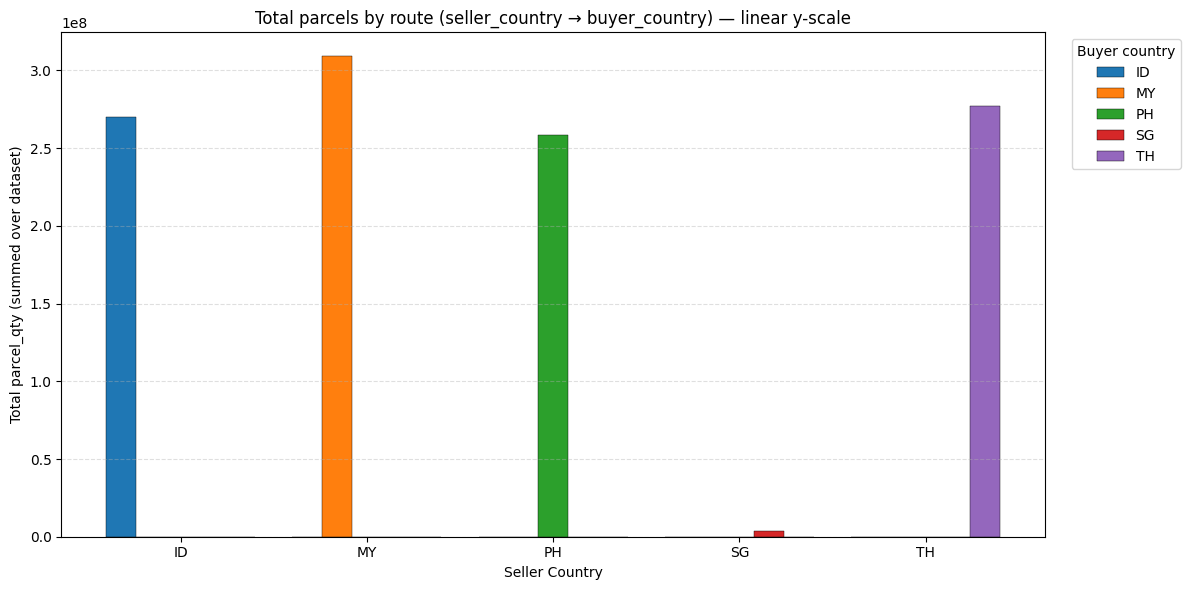

In [69]:
plot_route_grouped(llm_test_df, yscale="linear", out_file=None)

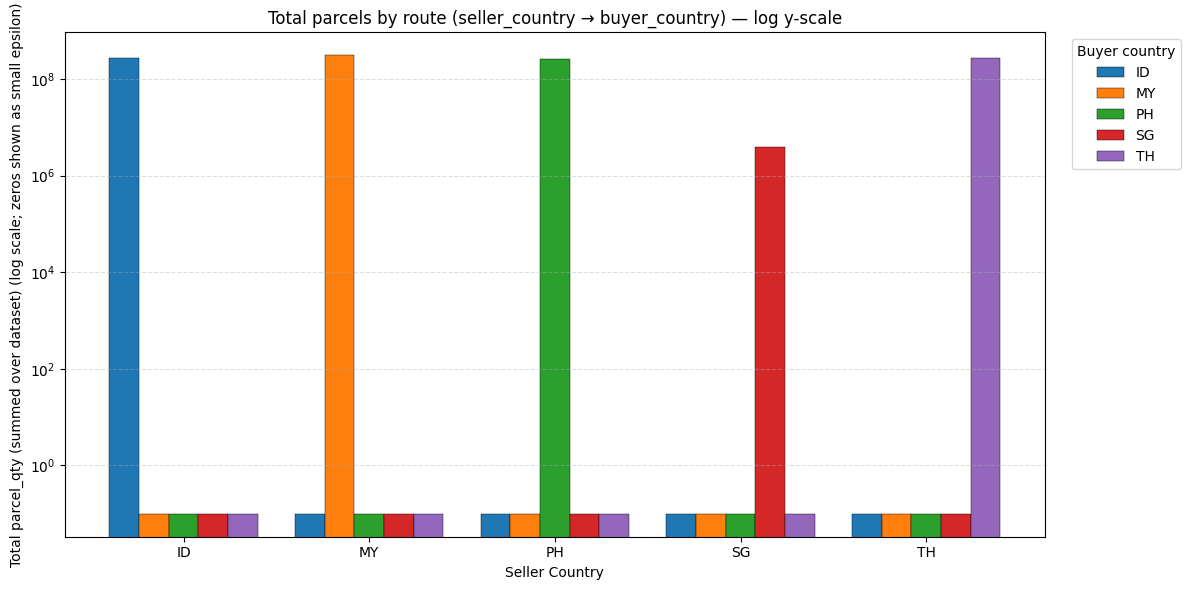

In [70]:
plot_route_grouped(llm_test_df, yscale="log", out_file=None)

In [96]:
seller = "MY"
buyer  = "SG"

route_df = llm_test_df[
    (llm_test_df["seller_country"] == seller) &
    (llm_test_df["buyer_country"] == buyer)
]

total_parcels = route_df["parcel_qty"].sum()
n_rows = len(route_df)
mean_per_row = route_df["parcel_qty"].mean()

print(f"Route {seller} -> {buyer}:")
print(f"  Rows (aggregate rows): {n_rows}")
print(f"  Total parcels: {total_parcels:,}")
print(f"  Mean parcels per row: {mean_per_row:.2f}")

# Optional: parcels by date (sorted). Uncomment the next line to see full series.
# print(route_df.groupby("dt")["parcel_qty"].sum().sort_index())
# Quick preview:
print("\nParcels by date (first 10):")
print(route_df.groupby("dt")["parcel_qty"].sum().sort_index().head(10))

Route MY -> SG:
  Rows (aggregate rows): 0
  Total parcels: 0
  Mean parcels per row: nan

Parcels by date (first 10):
Series([], Name: parcel_qty, dtype: int64)


Hm okay

In [110]:
llm_test_df[llm_test_df["sum_apt"] - llm_test_df["sum_bwt"] > 0].count()

dt                    202
buyer_country         202
buyer_region          202
seller_country        202
seller_region         200
logistics_provider    202
parcel_qty            202
sum_apt               202
sum_bwt               202
dtype: int64

Hm so does this mean that there are some rows' bwt is shorter than than apt? I think thats fine though, it is an average afterall

Total rows: 54,258
Unique logistics_providers: 11

Counts per logistics_provider:
                     rows     pct
logistics_provider               
Ninja Van           12940  23.849
J&T                 12873  23.726
Pos Malaysia         6239  11.499
Pos Indonesia        4734   8.725
Kerry Express        4490   8.275
DHL                  3919   7.223
2GO Express          2771   5.107
LBC Express          2667   4.915
SiCepat              2107   3.883
FedEx                1514   2.790
DB Schenker             4   0.007

Flagged (sparse) providers:
                    rows    pct
logistics_provider             
DB Schenker            4  0.007


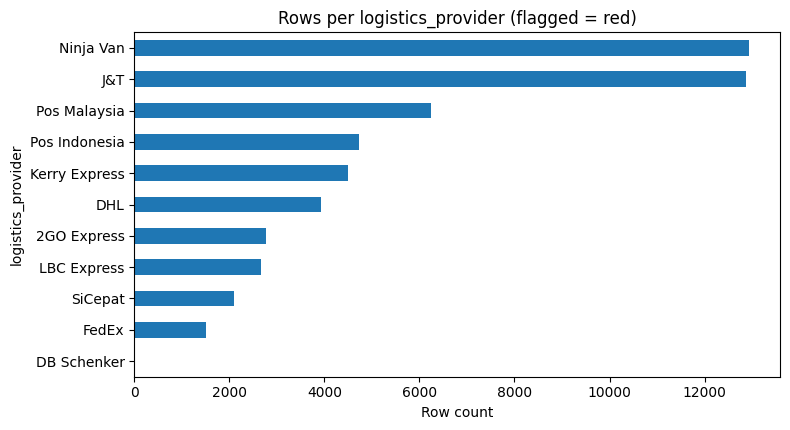

In [75]:
min_rows = 100          # flag providers with fewer than this many rows
min_pct = 0.005         # or flag if they represent < 0.5% of rows

counts = llm_test_df["logistics_provider"].value_counts(dropna=False)
total_rows = len(llm_test_df)
pct = counts / total_rows

print(f"Total rows: {total_rows:,}")
print(f"Unique logistics_providers: {counts.size}\n")

summary = pd.DataFrame({
    "rows": counts,
    "pct": (pct * 100).round(3)
})
print("Counts per logistics_provider:")
print(summary.sort_values("rows", ascending=False).to_string())

# Identify providers considered too sparse
flagged = summary[(summary["rows"] < min_rows) | (summary["pct"] < (min_pct * 100))].sort_values("rows")
if flagged.empty:
    print("\nNo logistics_provider flagged as sparse with the current thresholds.")
else:
    print("\nFlagged (sparse) providers:")
    print(flagged.to_string())

# Return values for programmatic use
flagged_providers = flagged.index.tolist()

# Quick visualization: horizontal bar chart, flagged in red
fig, ax = plt.subplots(figsize=(8, max(4, 0.4 * len(counts))))
colors = ["red" if p in flagged_providers else "#1f77b4" for p in counts.index]
counts.sort_values().plot.barh(color=[colors[counts.index.get_loc(i)] for i in counts.sort_values().index], ax=ax)
ax.set_xlabel("Row count")
ax.set_title("Rows per logistics_provider (flagged = red)")
plt.tight_layout()
plt.show()

In [78]:
llm_test_df[llm_test_df["logistics_provider"] == "DB Schenker"]["parcel_qty"].sum()

np.int64(90096)

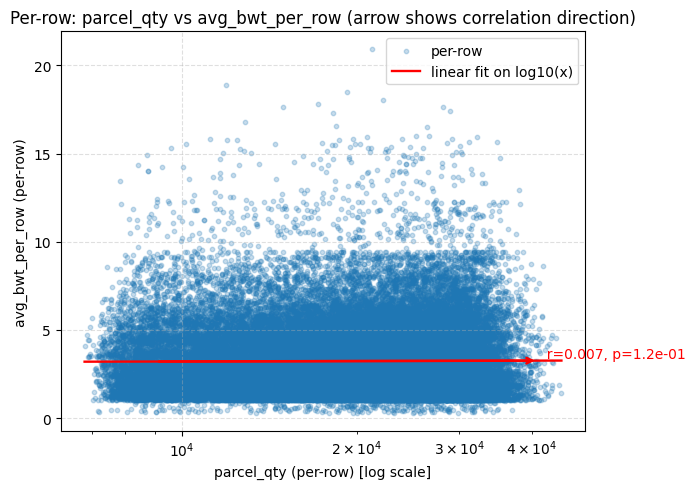

In [93]:
# prepare per-row data (same as you had)
perrow = llm_test_df.dropna(subset=["parcel_qty", "avg_bwt_per_row"])
perrow = perrow[perrow["parcel_qty"] > 0]

# x and y arrays
x = perrow["parcel_qty"].values
y = perrow["avg_bwt_per_row"].values
mask = np.isfinite(x) & np.isfinite(y) & (x > 0)

# do regression on log10(x) because we'll plot x on a log scale
logx = np.log10(x[mask])
yy = y[mask]

# linear regression (logx -> y)
slope, intercept, r_value, p_value, stderr = linregress(logx, yy)

# build smooth x-fit for plotting the fitted line
x_fit = np.logspace(np.log10(x[mask].min()), np.log10(x[mask].max()), 200)
y_fit = slope * np.log10(x_fit) + intercept

fig, ax = plt.subplots(figsize=(7, 5))

# scatter (per-row)
ax.scatter(x, y, s=10, alpha=0.25, label="per-row")

# regression line
ax.plot(x_fit, y_fit, color="red", lw=1.7, label="linear fit on log10(x)")

# arrow along the regression line to show correlation direction
start = np.percentile(x_fit, 15)
end = np.percentile(x_fit, 95)
y_start = slope * np.log10(start) + intercept
y_end = slope * np.log10(end) + intercept
ax.annotate(
    "",
    xy=(end, y_end),
    xytext=(start, y_start),
    arrowprops=dict(arrowstyle="->", color="red", lw=1.8),
)

# annotate correlation statistics
ax.text(end, y_end, f"  r={r_value:.3f}, p={p_value:.1e}", color="red", va="bottom")

ax.set_xscale("log")
ax.set_xlabel("parcel_qty (per-row) [log scale]")
ax.set_ylabel("avg_bwt_per_row (per-row)")
ax.set_title("Per-row: parcel_qty vs avg_bwt_per_row (arrow shows correlation direction)")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

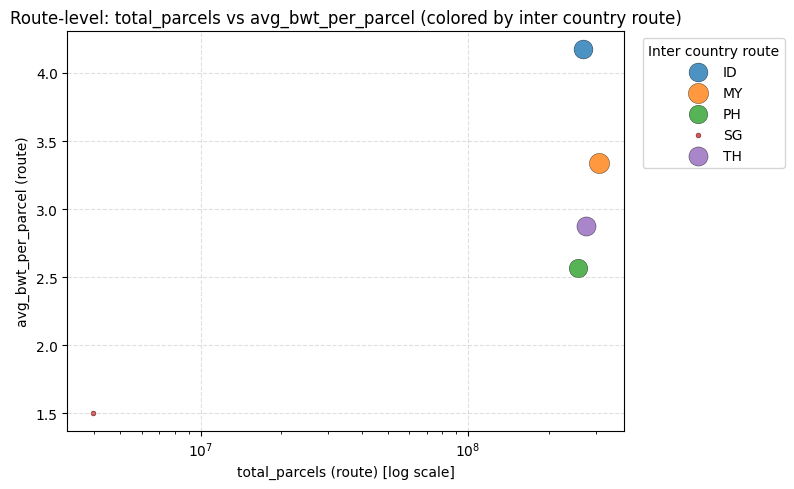

In [90]:
# ensure aggregation exists
route = (
    llm_test_df.groupby(["seller_country", "buyer_country"], dropna=False)
    .agg(total_parcels=("parcel_qty", "sum"), total_bwt=("sum_bwt", "sum"))
    .reset_index()
)
route = route[route["total_parcels"] > 0].copy()
route["avg_bwt_per_parcel"] = route["total_bwt"] / route["total_parcels"]

# prepare colors by buyer_country
buyers = sorted(route["buyer_country"].dropna().unique())
cmap = plt.get_cmap("tab10")
colors = {b: cmap(i % 10) for i, b in enumerate(buyers)}

fig, ax = plt.subplots(figsize=(8, 5))
group_width = 200  # max marker size reference

for b in buyers:
    mask = route["buyer_country"] == b
    sizes = (route.loc[mask, "total_parcels"] / route["total_parcels"].max()) * group_width + 10
    ax.scatter(
        route.loc[mask, "total_parcels"],
        route.loc[mask, "avg_bwt_per_parcel"],
        s=sizes,
        alpha=0.8,
        label=b,
        color=colors[b],
        edgecolor="k",
        linewidth=0.3,
    )

ax.set_xscale("log")
ax.set_xlabel("total_parcels (route) [log scale]")
ax.set_ylabel("avg_bwt_per_parcel (route)")
ax.set_title("Route-level: total_parcels vs avg_bwt_per_parcel (colored by inter country route)")
ax.grid(True, linestyle="--", alpha=0.4)

# legend (buyers)
ax.legend(title="Inter country route", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()